PyTorch: 2.11.0+cpu | Torchvision: 0.26.0+cpu
Device: cpu
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 158MB/s]



ResNet-50 loaded | 25,557,032 parameters
Final layer: Linear(in_features=2048, out_features=1000, bias=True)


Saving closeup-shot-beautiful-ginger-domestic-kitten-sitting-white-surface_181624-35913.avif to closeup-shot-beautiful-ginger-domestic-kitten-sitting-white-surface_181624-35913.avif

File: closeup-shot-beautiful-ginger-domestic-kitten-sitting-white-surface_181624-35913.avif | Size (W x H): (740, 740) | Mode: RGB


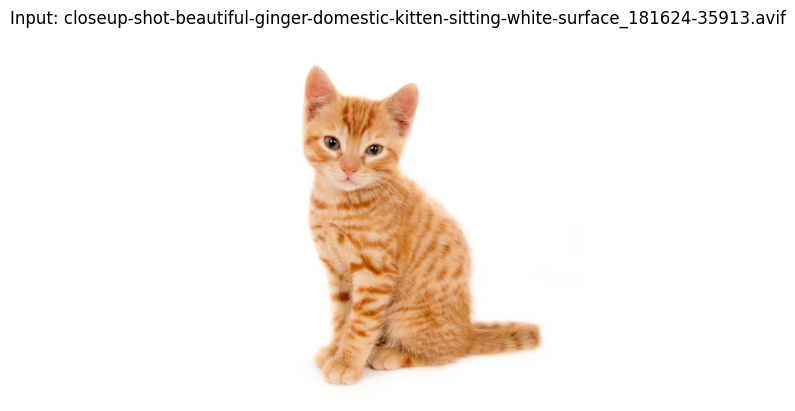


Tensor shape: (1, 3, 224, 224) | Dtype: torch.float32
Value range: -2.032 to 2.640   (mean-centred, no longer 0-1)

Top-left 5x5 of the red channel — the actual numbers the network sees:
[[2.2489083 2.2489083 2.2489083 2.2489083 2.2489083]
 [2.2489083 2.2489083 2.2489083 2.2489083 2.2489083]
 [2.2489083 2.2489083 2.2489083 2.2489083 2.2489083]
 [2.2489083 2.2489083 2.2489083 2.2489083 2.2489083]
 [2.2489083 2.2489083 2.2489083 2.2489083 2.2489083]]
Logits shape: (1, 1000)
Logit range: -1.310 to 6.720
Probabilities sum to: 1.0000

Total classes: 1000
First 5: ['tench', 'goldfish', 'great white shark', 'tiger shark', 'hammerhead']

Top-5 predictions
----------------------------------------------
1. tabby                         32.10%   (class 281)
2. Egyptian cat                  15.75%   (class 285)
3. tiger cat                      9.11%   (class 282)
4. lynx                           0.58%   (class 287)
5. Persian cat                    0.38%   (class 283)


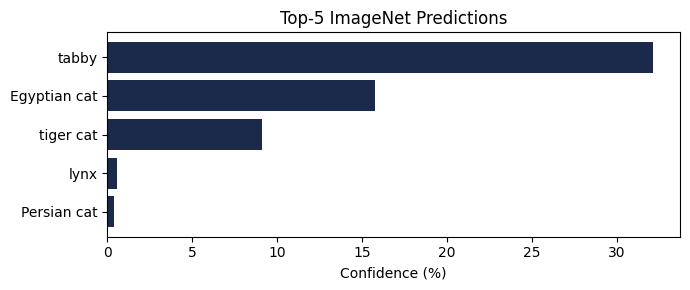

In [1]:
# ==============================================================
# Day 01 — Image Feature Extraction with a Pretrained CNN Backbone
# Miraat Gupta | PRN 23070126073 | Division A3
# Multimodal AI | Semester 7 | 13-07-2026
# ==============================================================

# ---------- Step 1: Import libraries ----------
import torch
import torch.nn as nn
import torchvision
from torchvision import models, transforms

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

print("PyTorch:", torch.__version__, "| Torchvision:", torchvision.__version__)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


# ---------- Step 2: Load pretrained CNN backbone ----------
weights = models.ResNet50_Weights.IMAGENET1K_V2
model   = models.resnet50(weights=weights)
model.eval()                    # inference mode: dropout off, BatchNorm stats frozen
model.to(device)

print(f"\nResNet-50 loaded | {sum(p.numel() for p in model.parameters()):,} parameters")
print("Final layer:", model.fc)          # 2048 -> 1000 ImageNet classes


# ---------- Step 3: Upload an image ----------
from google.colab import files

uploaded = files.upload()                # file picker
img_path = list(uploaded.keys())[0]
img      = Image.open(img_path).convert("RGB")   # force 3 channels

print("\nFile:", img_path, "| Size (W x H):", img.size, "| Mode:", img.mode)
plt.imshow(img); plt.axis("off"); plt.title(f"Input: {img_path}"); plt.show()


# ---------- Step 4: Preprocessing — image to numbers ----------
preprocess = transforms.Compose([
    transforms.Resize(256),              # shorter side -> 256 px, aspect ratio kept
    transforms.CenterCrop(224),          # 224x224 = ResNet's expected input size
    transforms.ToTensor(),               # PIL [0-255] -> FloatTensor [0,1], shape (C,H,W)
    transforms.Normalize(                # per-channel standardisation, ImageNet statistics
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]),
])

x = preprocess(img).unsqueeze(0).to(device)      # (1, 3, 224, 224) — batch dim added

print("\nTensor shape:", tuple(x.shape), "| Dtype:", x.dtype)
print(f"Value range: {x.min():.3f} to {x.max():.3f}   (mean-centred, no longer 0-1)")
print("\nTop-left 5x5 of the red channel — the actual numbers the network sees:")
print(x[0, 0, :5, :5].cpu().numpy())

# ---------- Step 5: Forward pass — run the image through the CNN ----------
with torch.no_grad():                     # no gradients needed for inference; saves memory
    logits = model(x)                     # (1, 1000) — raw, unnormalised scores

probs = torch.softmax(logits, dim=1)      # (1, 1000) — squashed to a distribution summing to 1

print("Logits shape:", tuple(logits.shape))
print(f"Logit range: {logits.min():.3f} to {logits.max():.3f}")
print(f"Probabilities sum to: {probs.sum().item():.4f}")


# ---------- Step 6: Download human-readable ImageNet labels ----------
import urllib.request

LABELS_URL = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"

try:
    with urllib.request.urlopen(LABELS_URL) as f:
        categories = [line.strip().decode("utf-8") for line in f]
except Exception as e:
    print("Download failed, using labels bundled with the weights:", e)
    categories = weights.meta["categories"]      # same 1000 classes, same order

print("\nTotal classes:", len(categories))
print("First 5:", categories[:5])
# The index of a class in this list == the index of its neuron in the output layer.


# ---------- Step 7: Top-5 predictions ----------
top5_prob, top5_idx = torch.topk(probs, k=5, dim=1)

top5_prob = top5_prob[0].cpu().numpy()
top5_idx  = top5_idx[0].cpu().numpy()

print("\nTop-5 predictions")
print("-" * 46)
for rank, (i, p) in enumerate(zip(top5_idx, top5_prob), start=1):
    print(f"{rank}. {categories[i]:<28} {p*100:6.2f}%   (class {i})")

plt.figure(figsize=(7, 3))
plt.barh([categories[i] for i in top5_idx][::-1], top5_prob[::-1] * 100, color="#1B2A4A")
plt.xlabel("Confidence (%)")
plt.title("Top-5 ImageNet Predictions")
plt.tight_layout()
plt.show()